In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv("data/insurance.csv")

In [3]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [4]:
print(dataset.head())

   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86


In [5]:
print(dataset.describe())

               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.000000    34.700000     2.000000  16639.915000
max      64.000000    53.100000     5.000000  63770.430000


In [6]:
dataset.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

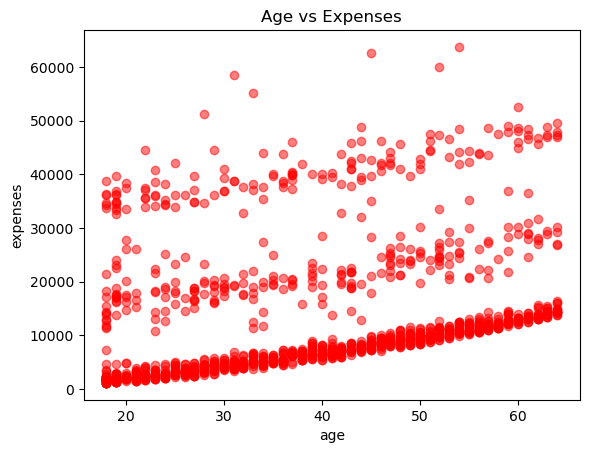

In [7]:
plt.scatter(dataset.age,dataset.expenses,c='r',alpha=0.5)
plt.xlabel("age")
plt.ylabel("expenses")
plt.title("Age vs Expenses")
plt.show()

Expenses generally increase with age, but the points form three distinct bands instead of a single line. This suggests that another variable also affects expenses.

In [8]:
X=dataset.iloc[:,0].values
y=dataset.iloc[:,-1].values

In [9]:
print(X)
print(y)

[19 18 28 ... 18 21 61]
[16884.92  1725.55  4449.46 ...  1629.83  2007.95 29141.36]


In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0,test_size=0.2)

In [11]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train.reshape(-1,1),y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred=regressor.predict(X_test.reshape(-1,1))
np.concatenate(
    (y_test.reshape(len(y_test), 1),
     y_pred.reshape(len(y_pred), 1)),
    axis=1
)

array([[ 9724.53      , 16278.18044007],
       [ 8547.69      , 15086.32260236],
       [45702.02      , 15324.6941699 ],
       [12950.07      , 18423.52454793],
       [ 9644.25      , 16039.80887253],
       [ 4500.34      , 11987.49222433],
       [ 2198.19      ,  8173.54714368],
       [11436.74      , 16039.80887253],
       [ 7537.16      , 12940.9784945 ],
       [ 5425.02      , 11272.37752171],
       [ 6753.04      , 11987.49222433],
       [10493.95      , 15801.43730499],
       [ 7337.75      , 14132.8363322 ],
       [ 4185.1       , 11749.12065679],
       [18310.74      , 10318.89125155],
       [10702.64      , 15801.43730499],
       [12523.6       , 18185.15298039],
       [ 3490.55      , 10080.51968401],
       [ 6457.84      , 12940.9784945 ],
       [33475.82      ,  8650.29027877],
       [23967.38      , 16039.80887253],
       [12643.38      , 17231.66671023],
       [23045.57      , 16278.18044007],
       [23065.42      , 15086.32260236],
       [ 1674.63

In [13]:
from sklearn.metrics import r2_score,mean_absolute_error
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(r2)
print(mae)


0.1253912041940104
9147.177394679715


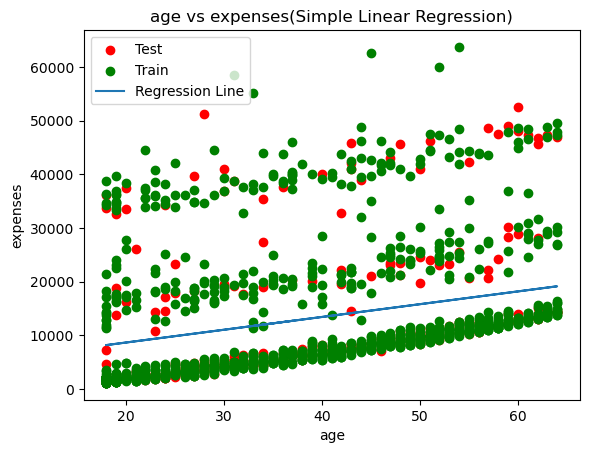

In [14]:
plt.scatter(X_test,y_test,c='r',label='Test')
plt.scatter(X_train,y_train,c='g',label='Train')
plt.plot(X_train,regressor.predict(X_train.reshape(-1,1)),label='Regression Line')
plt.xlabel("age")
plt.ylabel("expenses")
plt.title("age vs expenses(Simple Linear Regression)")
plt.legend()
plt.show()

In [15]:
print(regressor.coef_)
print(regressor.intercept_)

[238.37156754]
3882.8589279511343


## Results and Interpretation

**Coefficient:** The coefficient of `age` is about [X]. This means that, on average, each additional year of age increases expenses by roughly $[X].

**Intercept:** The intercept is [Y], which is the model's prediction for age = 0. This has no real meaning here, because the youngest person in the dataset is 18 years old. Predicting outside the range of the training data (extrapolation) is unreliable, so the intercept is only the point where the line crosses the y-axis.

**Model performance:** On the test set, R² is about 0.13 and MAE is about $9,147. The error is large compared to the mean expense (about $13,270), so age alone is a weak predictor.

**Conclusion:** Age explains only a small part of the variation in expenses. The scatter plot shows three separate bands, which means other variables also affect expenses. The next step is to include more features using multiple linear regression.